# SVM

#### Imports

In [9]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.svm_experiment import SVMExperiment
from src.utils import evaluate_model, save_results

## Experimento 1: Conjunto com todas as Features

In [10]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### SVM - Default

In [11]:
from sklearn.svm import SVC

svm_exp1 = SVC(kernel='rbf', probability=True, random_state=14)
svm_exp1.fit(X_train_exp1, y_train_exp1)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


=== Métricas svm_def_exp1  ===
    Acurácia: 0.8108
    Precisão: 0.7996
    Recall:   0.7517
    F1-Score: 0.7673
    MCC:      0.5492
    AUC:      0.8611


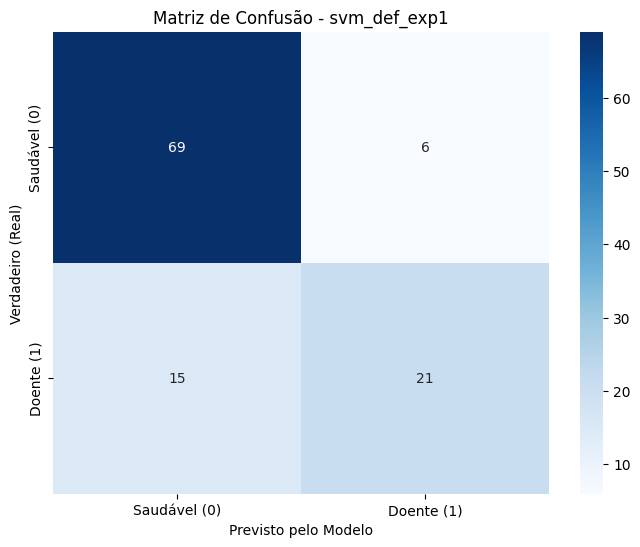

In [12]:
# Avaliar modelo
y_pred_def_exp1 = svm_exp1.predict(X_test_exp1)
y_prob_def_exp1 = svm_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'svm_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'svm_def_exp1', caminho)

### SVM - Melhorado

In [13]:
# Criar o experimento
experimento_1 = SVMExperiment(X_train_exp1, y_train_exp1, 'svm_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_svm = experimento_1.best_model

[I 2026-08-16 15:09:17,052] A new study created in memory with name: no-name-b7cc8cf4-17aa-4498-b966-2e0f09ecde55


Iniciando otimização do cenário svm_otz_exp1.


Best trial: 0. Best value: 0.670513:   2%|▏         | 1/50 [00:06<05:16,  6.45s/it]

[I 2026-08-16 15:09:23,500] Trial 0 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 0.9011649799544813, 'gamma': 'scale', 'tol': 3.910252567300605e-05, 'shrinking': True, 'coef0': 0.7490888886137752}. Best is trial 0 with value: 0.6705128205128205.


Best trial: 1. Best value: 0.814178:   4%|▍         | 2/50 [00:10<04:12,  5.26s/it]

[I 2026-08-16 15:09:27,944] Trial 1 finished with value: 0.8141779788838612 and parameters: {'kernel': 'poly', 'C': 1.1233725114374868, 'gamma': 'scale', 'tol': 0.00011901154564496648, 'shrinking': True, 'degree': 2, 'coef0': 0.5399932447431727}. Best is trial 1 with value: 0.8141779788838612.


Best trial: 1. Best value: 0.814178:   8%|▊         | 4/50 [00:13<01:57,  2.56s/it]

[I 2026-08-16 15:09:30,773] Trial 2 finished with value: 0.6705128205128205 and parameters: {'kernel': 'rbf', 'C': 0.10120239491522433, 'gamma': 'scale', 'tol': 0.007722273240129355, 'shrinking': True}. Best is trial 1 with value: 0.8141779788838612.
[I 2026-08-16 15:09:30,906] Trial 3 finished with value: 0.7597285067873303 and parameters: {'kernel': 'poly', 'C': 9.960933567443723, 'gamma': 'scale', 'tol': 6.455360017150116e-05, 'shrinking': True, 'degree': 3, 'coef0': 0.6455983774028116}. Best is trial 1 with value: 0.8141779788838612.
[I 2026-08-16 15:09:30,948] Trial 4 finished with value: 0.8105580693815988 and parameters: {'kernel': 'rbf', 'C': 3.9113571639004268, 'gamma': 'auto', 'tol': 5.3424829129885716e-05, 'shrinking': False}. Best is trial 1 with value: 0.8141779788838612.


Best trial: 8. Best value: 0.829563:  20%|██        | 10/50 [00:14<00:21,  1.87it/s]

[I 2026-08-16 15:09:30,977] Trial 5 finished with value: 0.6705128205128205 and parameters: {'kernel': 'poly', 'C': 0.9476116667492588, 'gamma': 'auto', 'tol': 0.07309553632888477, 'shrinking': False, 'degree': 3, 'coef0': 0.21698935479046022}. Best is trial 1 with value: 0.8141779788838612.
[I 2026-08-16 15:09:31,016] Trial 6 finished with value: 0.7909502262443439 and parameters: {'kernel': 'rbf', 'C': 8.976464617062632, 'gamma': 'scale', 'tol': 0.054966495054482756, 'shrinking': False}. Best is trial 1 with value: 0.8141779788838612.
[I 2026-08-16 15:09:31,069] Trial 7 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 0.7441744799261218, 'gamma': 'scale', 'tol': 0.017947323566352574, 'shrinking': False, 'coef0': 0.9703381845242753}. Best is trial 1 with value: 0.8141779788838612.
[I 2026-08-16 15:09:31,112] Trial 8 finished with value: 0.8295625942684767 and parameters: {'kernel': 'poly', 'C': 2.036491238839273, 'gamma': 'scale', 'tol': 0.00308238083

Best trial: 8. Best value: 0.829563:  26%|██▌       | 13/50 [00:14<00:14,  2.59it/s]

[I 2026-08-16 15:09:31,196] Trial 10 finished with value: 0.6705128205128205 and parameters: {'kernel': 'poly', 'C': 0.14161775471505025, 'gamma': 'auto', 'tol': 0.0014165599712429276, 'shrinking': False, 'degree': 2, 'coef0': 0.040608799071346235}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,256] Trial 11 finished with value: 0.8217948717948718 and parameters: {'kernel': 'poly', 'C': 98.03909569947855, 'gamma': 'auto', 'tol': 0.002013123723654739, 'shrinking': False, 'degree': 4, 'coef0': 0.9811696264217172}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,303] Trial 12 finished with value: 0.8179487179487179 and parameters: {'kernel': 'poly', 'C': 55.59540537015217, 'gamma': 'auto', 'tol': 0.0008307625597324737, 'shrinking': False, 'degree': 4, 'coef0': 0.9998032506544318}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,336] Trial 13 finished with value: 0.8142533936651585 and parameters: {'kernel': 'poly', 'C'

Best trial: 8. Best value: 0.829563:  34%|███▍      | 17/50 [00:14<00:06,  5.14it/s]

[I 2026-08-16 15:09:31,380] Trial 14 finished with value: 0.814027149321267 and parameters: {'kernel': 'poly', 'C': 2.908830968722073, 'gamma': 'scale', 'tol': 0.00037825552426168336, 'shrinking': False, 'degree': 2, 'coef0': 0.3747073870375086}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,426] Trial 15 finished with value: 0.806711915535445 and parameters: {'kernel': 'sigmoid', 'C': 25.758131893238595, 'gamma': 'auto', 'tol': 0.005438580892340582, 'shrinking': False, 'coef0': 0.8335847368479994}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,488] Trial 16 finished with value: 0.7868778280542987 and parameters: {'kernel': 'poly', 'C': 0.29202840956652515, 'gamma': 'scale', 'tol': 0.004814338721397498, 'shrinking': False, 'degree': 4, 'coef0': 0.8644537682428344}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,525] Trial 17 finished with value: 0.7052036199095022 and parameters: {'kernel': 'poly', 'C': 3.3157883

Best trial: 8. Best value: 0.829563:  46%|████▌     | 23/50 [00:14<00:02,  9.49it/s]

[I 2026-08-16 15:09:31,565] Trial 18 finished with value: 0.8180995475113123 and parameters: {'kernel': 'rbf', 'C': 99.45327448149357, 'gamma': 'auto', 'tol': 0.000284938735534885, 'shrinking': True}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,606] Trial 19 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 32.07813960872791, 'gamma': 'scale', 'tol': 0.019678974348945763, 'shrinking': False, 'coef0': 0.7526900268017539}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,661] Trial 20 finished with value: 0.8257164404223227 and parameters: {'kernel': 'poly', 'C': 2.1430251190864653, 'gamma': 'scale', 'tol': 0.003109855455828155, 'shrinking': False, 'degree': 2, 'coef0': 0.9233867989080481}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,703] Trial 21 finished with value: 0.8295625942684767 and parameters: {'kernel': 'poly', 'C': 2.065049076180995, 'gamma': 'scale', 'tol': 0.002635977

Best trial: 26. Best value: 0.829638:  54%|█████▍    | 27/50 [00:14<00:01, 11.66it/s]

[I 2026-08-16 15:09:31,779] Trial 23 finished with value: 0.8180995475113122 and parameters: {'kernel': 'poly', 'C': 0.3682109029465003, 'gamma': 'scale', 'tol': 0.0028275066089616927, 'shrinking': False, 'degree': 2, 'coef0': 0.7094731629466416}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,842] Trial 24 finished with value: 0.8063348416289593 and parameters: {'kernel': 'poly', 'C': 4.776575856155279, 'gamma': 'scale', 'tol': 0.0006517994246301696, 'shrinking': False, 'degree': 2, 'coef0': 0.9055996490538625}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,886] Trial 25 finished with value: 0.8257164404223227 and parameters: {'kernel': 'poly', 'C': 1.9115745089947573, 'gamma': 'scale', 'tol': 0.003810368591940511, 'shrinking': False, 'degree': 2, 'coef0': 0.7833039090141898}. Best is trial 8 with value: 0.8295625942684767.
[I 2026-08-16 15:09:31,920] Trial 26 finished with value: 0.8296380090497738 and parameters: {'kernel': 'poly', 'C

Best trial: 26. Best value: 0.829638:  64%|██████▍   | 32/50 [00:15<00:01, 16.38it/s]

[I 2026-08-16 15:09:31,988] Trial 28 finished with value: 0.7673453996983409 and parameters: {'kernel': 'rbf', 'C': 0.21906462080330172, 'gamma': 'scale', 'tol': 0.029189230894587498, 'shrinking': True}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,034] Trial 29 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 0.5979225754018039, 'gamma': 'scale', 'tol': 0.00027497454155977287, 'shrinking': True, 'coef0': 0.1650955250949978}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,085] Trial 30 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 1.3500868778718962, 'gamma': 'scale', 'tol': 0.0005795445894003957, 'shrinking': True, 'coef0': 0.5276113899753583}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,118] Trial 31 finished with value: 0.8142533936651585 and parameters: {'kernel': 'poly', 'C': 0.3947657438710262, 'gamma': 'scale', 'tol': 0.0079881708

Best trial: 26. Best value: 0.829638:  76%|███████▌  | 38/50 [00:15<00:00, 19.94it/s]

[I 2026-08-16 15:09:32,196] Trial 33 finished with value: 0.7791101055806938 and parameters: {'kernel': 'poly', 'C': 1.1837066034755475, 'gamma': 'scale', 'tol': 0.028014270375202564, 'shrinking': True, 'degree': 3, 'coef0': 0.6041935732282313}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,230] Trial 34 finished with value: 0.8219457013574661 and parameters: {'kernel': 'poly', 'C': 0.6283737766553454, 'gamma': 'scale', 'tol': 0.005777890769408854, 'shrinking': True, 'degree': 2, 'coef0': 0.2791745972015782}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,282] Trial 35 finished with value: 0.7945701357466064 and parameters: {'kernel': 'poly', 'C': 6.4091881326886355, 'gamma': 'scale', 'tol': 0.013205413849967061, 'shrinking': True, 'degree': 2, 'coef0': 0.7047302167424234}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,318] Trial 36 finished with value: 0.8181749622926094 and parameters: {'kernel': 'poly', 'C'

Best trial: 26. Best value: 0.829638:  84%|████████▍ | 42/50 [00:15<00:00, 21.19it/s]

[I 2026-08-16 15:09:32,395] Trial 38 finished with value: 0.8144796380090498 and parameters: {'kernel': 'poly', 'C': 0.11075168500168331, 'gamma': 'scale', 'tol': 0.03136688345737206, 'shrinking': True, 'degree': 2, 'coef0': 0.5468186978723959}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,430] Trial 39 finished with value: 0.8219457013574661 and parameters: {'kernel': 'poly', 'C': 0.8009231860990141, 'gamma': 'scale', 'tol': 0.0930365799062507, 'shrinking': True, 'degree': 2, 'coef0': 0.7811741408001638}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,481] Trial 40 finished with value: 0.8104072398190045 and parameters: {'kernel': 'rbf', 'C': 0.513450437567682, 'gamma': 'scale', 'tol': 0.00772387396361173, 'shrinking': True}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,513] Trial 41 finished with value: 0.8180995475113122 and parameters: {'kernel': 'poly', 'C': 0.4155113137962476, 'gamma': 'scale', 'tol': 

Best trial: 26. Best value: 0.829638:  94%|█████████▍| 47/50 [00:15<00:00, 23.27it/s]

[I 2026-08-16 15:09:32,581] Trial 43 finished with value: 0.8258672699849171 and parameters: {'kernel': 'poly', 'C': 0.2612710055883573, 'gamma': 'scale', 'tol': 0.005573167275962806, 'shrinking': True, 'degree': 2, 'coef0': 0.3264619942679683}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,615] Trial 44 finished with value: 0.8258672699849171 and parameters: {'kernel': 'poly', 'C': 0.22080160757409206, 'gamma': 'scale', 'tol': 0.00406749303402992, 'shrinking': True, 'degree': 2, 'coef0': 0.16622794392927975}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,676] Trial 45 finished with value: 0.8217948717948718 and parameters: {'kernel': 'poly', 'C': 0.29621879130781587, 'gamma': 'scale', 'tol': 0.0018702550481027134, 'shrinking': True, 'degree': 3, 'coef0': 0.30568056971395574}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,711] Trial 46 finished with value: 0.8143288084464556 and parameters: {'kernel': 'poly',

Best trial: 26. Best value: 0.829638: 100%|██████████| 50/50 [00:15<00:00,  3.17it/s]

[I 2026-08-16 15:09:32,788] Trial 48 finished with value: 0.6705128205128205 and parameters: {'kernel': 'sigmoid', 'C': 1.5816285340597216, 'gamma': 'scale', 'tol': 0.0058520818904731885, 'shrinking': False, 'coef0': 0.9360914091455923}. Best is trial 26 with value: 0.8296380090497738.
[I 2026-08-16 15:09:32,841] Trial 49 finished with value: 0.7753393665158371 and parameters: {'kernel': 'poly', 'C': 2.4384730204640426, 'gamma': 'scale', 'tol': 0.0029118335790493765, 'shrinking': True, 'degree': 3, 'coef0': 0.38024460895724393}. Best is trial 26 with value: 0.8296380090497738.
Melhor pontuação (CV): 0.8296
Melhores parâmetros:
{'kernel': 'poly', 'C': 0.4694698915783192, 'gamma': 'scale', 'tol': 0.00940487722172228, 'shrinking': True, 'degree': 2, 'coef0': 0.5490593028027686}


In [14]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== Métricas svm_otz_exp1  ===
    Acurácia: 0.8108
    Precisão: 0.7939
    Recall:   0.7589
    F1-Score: 0.7716
    MCC:      0.5517
    AUC:      0.8533


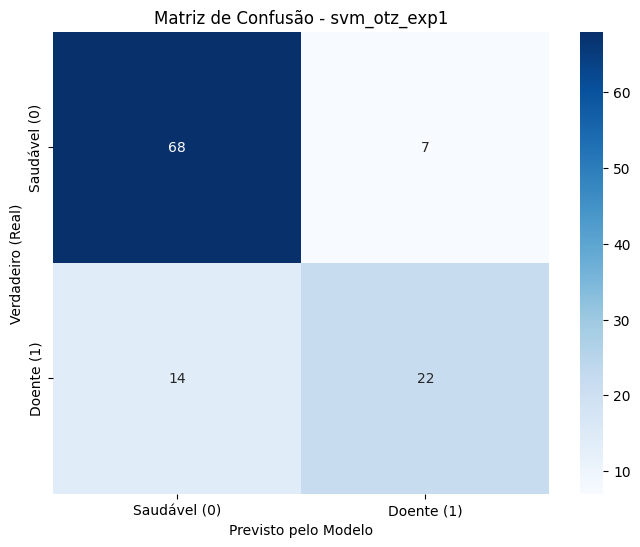

In [16]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'svm_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'svm_otz_exp1', caminho)